# IMPORTS

In [1]:
import json
import gzip
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

from collections import Counter
from nltk.corpus import stopwords
# Enhancement
from nltk.corpus import sentiwordnet as swn
from nltk.corpus import wordnet as wn
# 
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [3]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
# Enhancement
nltk.download("sentiwordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

True

# LOAD DATA

In [4]:
DATA_PATH = "data/Appliances_5.json.gz"

def load_amazon_gz(path):
    """Load a gzipped JSON-lines file into a DataFrame."""
    records = []
    with gzip.open(path, "rb") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)


df = load_amazon_gz(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} reviews, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}\n")

Dataset loaded: 2277 reviews, 12 columns
Columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'image']



# DATA EXPLORATION

In [5]:
print("\n--- Basic Info ---")
print(df.dtypes)
print(f"\nTotal reviews       : {len(df)}")
print(f"Unique products     : {df['asin'].nunique()}")
print(f"Unique reviewers    : {df['reviewerID'].nunique()}")
print(f"Date range          : {df['reviewTime'].min()} – {df['reviewTime'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


--- Basic Info ---
overall           float64
verified             bool
reviewTime            str
reviewerID            str
asin                  str
style              object
reviewerName          str
reviewText            str
summary               str
unixReviewTime      int64
vote                  str
image              object
dtype: object

Total reviews       : 2277
Unique products     : 48
Unique reviewers    : 47
Date range          : 01 1, 2015 – 12 6, 2016

Missing values:
overall              0
verified             0
reviewTime           0
reviewerID           0
asin                 0
style             2239
reviewerName         0
reviewText           0
summary              0
unixReviewTime       0
vote               203
image             1449
dtype: int64


In [6]:
print("\n--- Rating Distribution ---")
print(df["overall"].value_counts().sort_index())


--- Rating Distribution ---
overall
1.0       9
2.0      13
3.0     421
4.0     222
5.0    1612
Name: count, dtype: int64


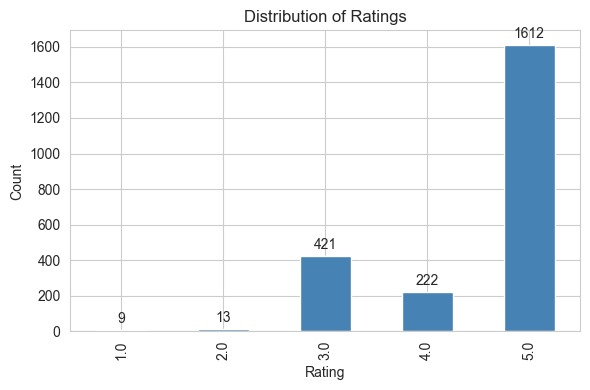

In [7]:
# Enhancement
fig, ax = plt.subplots(figsize=(6, 4))
df["overall"].value_counts().sort_index().plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.bar_label(ax.containers[0], label_type="edge", padding=3)
plt.tight_layout()
plt.savefig("outputs/rating_distribution_with_labels.png", dpi=150)
plt.show()

In [8]:
reviews_per_product = df.groupby("asin").size()
print("\n--- Reviews Per Product ---")
print(reviews_per_product.describe())


--- Reviews Per Product ---
count      48.000000
mean       47.437500
std       293.747388
min         1.000000
25%         2.000000
50%         5.000000
75%         7.000000
max      2040.000000
dtype: float64


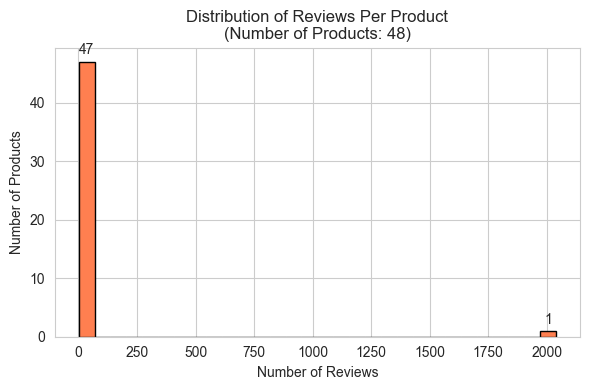

In [9]:
# Enhancement
fig, ax = plt.subplots(figsize=(6, 4))
# Capture the output of hist to access the patches if needed, 
# though containers[0] works fine for bar_label
reviews_per_product.hist(bins=30, color="coral", edgecolor="black", ax=ax)

# ax.set_title("Distribution of Reviews Per Product")
ax.set_title(f"Distribution of Reviews Per Product\n(Number of Products: {len(reviews_per_product)})")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Number of Products")

# 1. Get the container
container = ax.containers[0]

# 2. Create a list of labels: only show the value if it's > 0
# datavalues contains the height (count) of each bin
labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]

# 3. Pass the custom labels to bar_label
plt.bar_label(container, labels=labels, label_type="edge", padding=3)

plt.tight_layout()
plt.savefig("outputs/reviews_per_product.png", dpi=150)
plt.show()

In [10]:
reviews_per_user = df.groupby("reviewerID").size()
print("\n--- Reviews Per User ---")
print(reviews_per_user.describe())


--- Reviews Per User ---
count     47.000000
mean      48.446809
std       82.799341
min        5.000000
25%        5.000000
50%        6.000000
75%        8.000000
max      206.000000
dtype: float64


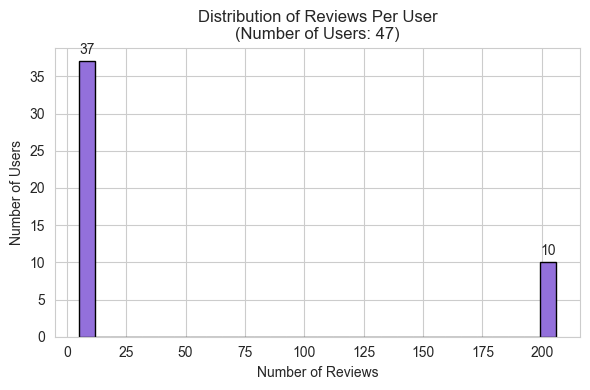

In [11]:
# Enhancement
fig, ax = plt.subplots(figsize=(6, 4))
reviews_per_user.hist(bins=30, color="mediumpurple", edgecolor="black", ax=ax)
ax.set_title(f"Distribution of Reviews Per User\n(Number of Users: {len(reviews_per_user)})")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Number of Users")
# 1. Get the container
container = ax.containers[0]

# 2. Create a list of labels: only show the value if it's > 0
# datavalues contains the height (count) of each bin
labels = [f'{int(v)}' if v > 0 else '' for v in container.datavalues]

# 3. Pass the custom labels to bar_label
plt.bar_label(container, labels=labels, label_type="edge", padding=3)
plt.tight_layout()
plt.savefig("outputs/reviews_per_user.png", dpi=150)
plt.show()

In [12]:
df["reviewText"] = df["reviewText"].fillna("")
df["review_length"] = df["reviewText"].apply(len)
df["review_word_count"] = df["reviewText"].apply(lambda x: len(x.split()))

print("\n--- Review Length (characters) ---")
print(df["review_length"].describe())

print("\n--- Review Word Count ---")
print(df["review_word_count"].describe())


--- Review Length (characters) ---
count    2277.000000
mean     1481.945103
std       848.284016
min         2.000000
25%       971.000000
50%      1198.000000
75%      1864.000000
max      3932.000000
Name: review_length, dtype: float64

--- Review Word Count ---
count    2277.000000
mean      287.505929
std       161.640463
min         1.000000
25%       188.000000
50%       242.000000
75%       371.000000
max       650.000000
Name: review_word_count, dtype: float64


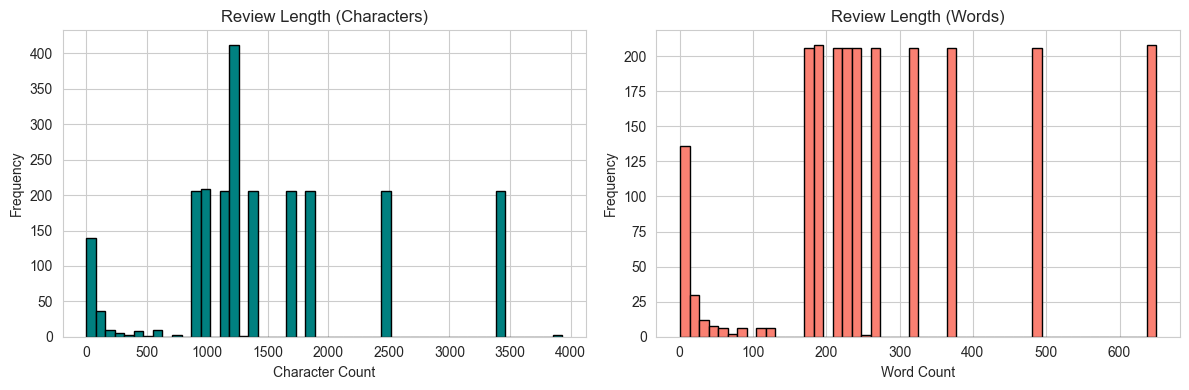

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["review_length"].hist(bins=50, color="teal", edgecolor="black", ax=axes[0])
axes[0].set_title("Review Length (Characters)")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

df["review_word_count"].hist(bins=50, color="salmon", edgecolor="black", ax=axes[1])
axes[1].set_title("Review Length (Words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("outputs/review_lengths.png", dpi=150)
plt.show()


--- Outliers (IQR method on word count) ---
Lower bound: -86, Upper bound: 646
Number of outlier reviews: 208


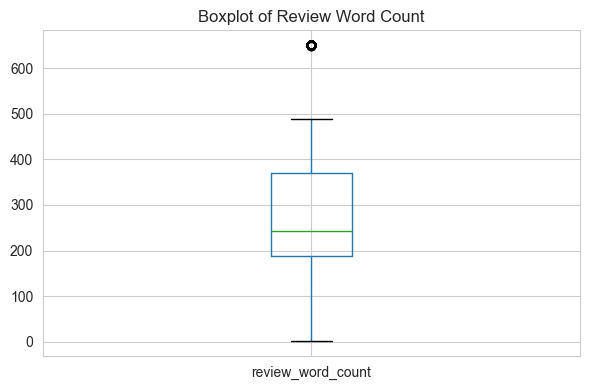

In [14]:
q1 = df["review_word_count"].quantile(0.25)
q3 = df["review_word_count"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[
    (df["review_word_count"] < lower_bound)
    | (df["review_word_count"] > upper_bound)
]
print(f"\n--- Outliers (IQR method on word count) ---")
print(f"Lower bound: {lower_bound:.0f}, Upper bound: {upper_bound:.0f}")
print(f"Number of outlier reviews: {len(outliers)}")

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="review_word_count", ax=ax)
ax.set_title("Boxplot of Review Word Count")
plt.tight_layout()
plt.savefig("outputs/review_wordcount_boxplot.png", dpi=150)
plt.show()

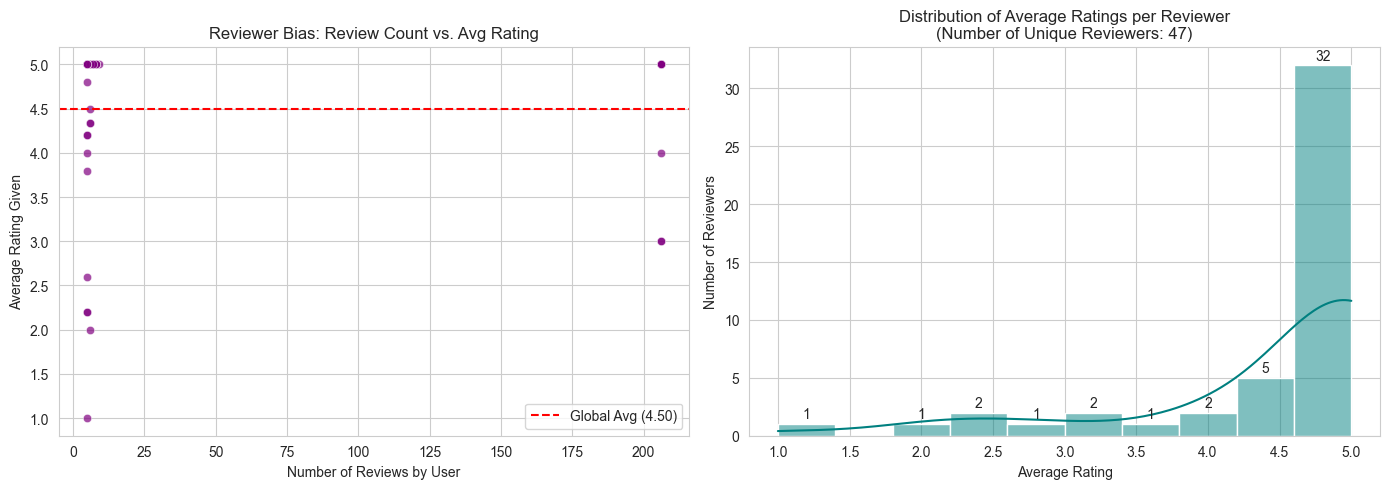

In [15]:
# Enhancement

# --- Map ReviewerID with Reviews to Check for Bias ---

# Group by reviewerID to get review count and average rating
reviewer_stats = df.groupby('reviewerID').agg(
    review_count=('asin', 'count'),
    avg_rating=('overall', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Scatter plot to check for bias (Review Count vs Avg Rating)
sns.scatterplot(x='review_count', y='avg_rating', data=reviewer_stats, alpha=0.7, color='purple', ax=axes[0])
axes[0].set_title("Reviewer Bias: Review Count vs. Avg Rating")
axes[0].set_xlabel("Number of Reviews by User")
axes[0].set_ylabel("Average Rating Given")
# Add a red dashed line representing the global average rating
global_avg = df['overall'].mean()
axes[0].axhline(global_avg, color='red', linestyle='--', label=f'Global Avg ({global_avg:.2f})')
axes[0].legend()

# Plot B: Histogram of Average Ratings across reviewers with distribution labeling
sns.histplot(reviewer_stats['avg_rating'], bins=10, kde=True, color='teal', ax=axes[1])
axes[1].set_title(f"Distribution of Average Ratings per Reviewer\n(Number of Unique Reviewers: {len(reviewer_stats)})")
axes[1].set_xlabel("Average Rating")
axes[1].set_ylabel("Number of Reviewers")

# Add exact count labels to the top of the histogram bars
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, f'{int(height)}', ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/reviewer_bias_analysis.png", dpi=150)
plt.show()

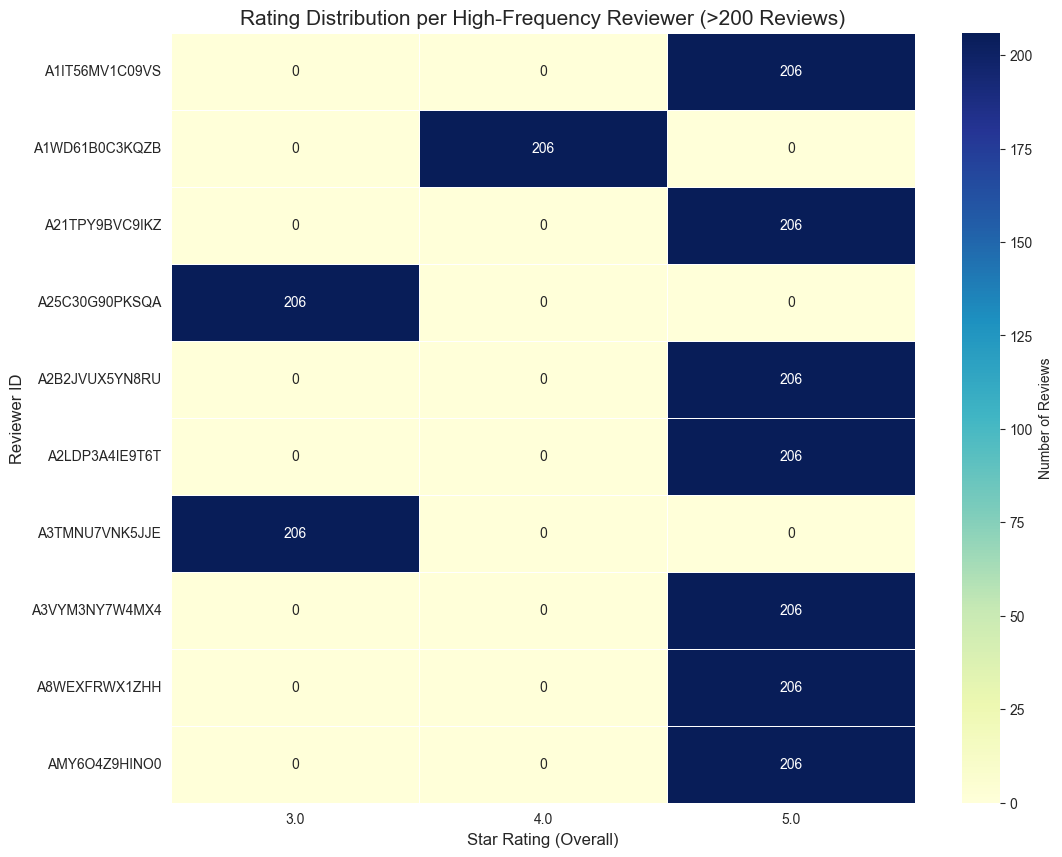

In [16]:
# Enhancement
# --- Heatmap of Rating Distribution for High-Frequency Reviewers ---
# 1. Filter the original dataframe to keep only 'high-frequency' reviewers
# .filter() keeps the original rows for any group that meets the condition
high_freq_df = df.groupby('reviewerID').filter(lambda x: len(x) > 200)

# 2. Create a distribution matrix using crosstab
# Rows: Reviewer IDs | Columns: Ratings (1, 2, 3, 4, 5) | Values: Count
rating_dist = pd.crosstab(high_freq_df['reviewerID'], high_freq_df['overall'])

# 3. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    rating_dist, 
    annot=True,          # Displays the actual counts inside each cell
    fmt='d',             # Formats the numbers as integers
    cmap='YlGnBu',       # A "Yellow-Green-Blue" color palette (darker = more reviews)
    linewidths=.5,       # Adds a small gap between cells for clarity
    cbar_kws={'label': 'Number of Reviews'}
)

plt.title('Rating Distribution per High-Frequency Reviewer (>200 Reviews)', fontsize=15)
plt.xlabel('Star Rating (Overall)', fontsize=12)
plt.ylabel('Reviewer ID', fontsize=12)

# Save the plot
plt.savefig('reviewer_rating_heatmap.png', bbox_inches='tight')

In [17]:
duplicate_count = df.duplicated(subset=["reviewerID", "asin", "reviewText"]).sum()
print(f"\n--- Duplicates ---")
print(f"Duplicate reviews (same user, product, text): {duplicate_count}")

# Remove exact duplicates if any
df = df.drop_duplicates(subset=["reviewerID", "asin", "reviewText"]).reset_index(
    drop=True
)
print(f"Dataset after duplicate removal: {len(df)} reviews")

# Average rating
print(f"\n--- Averages ---")
print(f"Mean rating: {df['overall'].mean():.2f}")
print(f"Median rating: {df['overall'].median():.1f}")

# Verified vs unverified
if "verified" in df.columns:
    print(f"\nVerified purchases: {df['verified'].sum()}")
    print(f"Unverified purchases: {(~df['verified']).sum()}")


--- Duplicates ---
Duplicate reviews (same user, product, text): 2074
Dataset after duplicate removal: 203 reviews

--- Averages ---
Mean rating: 4.59
Median rating: 5.0

Verified purchases: 180
Unverified purchases: 23


# TEXT PRE-PROCESSING & LABELING

Label based on rating
We map the star rating to sentiment classes to create ground truth labels for evaluating lexicon-based classifiers.


--- Sentiment Label Distribution ---
sentiment
Positive    178
Negative     16
Neutral       9
Name: count, dtype: int64


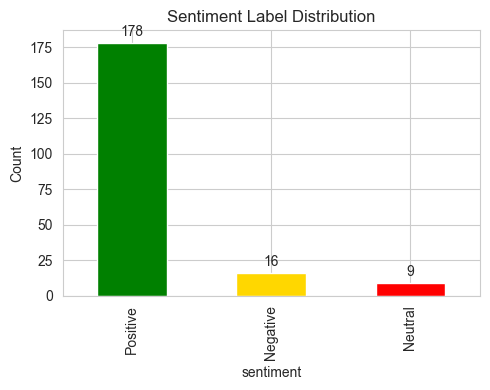

In [18]:
def label_sentiment(rating):
    """Map numeric rating to sentiment label."""
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"


df["sentiment"] = df["overall"].apply(label_sentiment)
print("\n--- Sentiment Label Distribution ---")
print(df["sentiment"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df["sentiment"].value_counts().plot(
    kind="bar",
    color=["green", "gold", "red"],
    ax=ax,
)
ax.set_title("Sentiment Label Distribution")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0], label_type="edge", padding=3)
plt.tight_layout()
plt.savefig("outputs/sentiment_distribution.png", dpi=150)
plt.show()

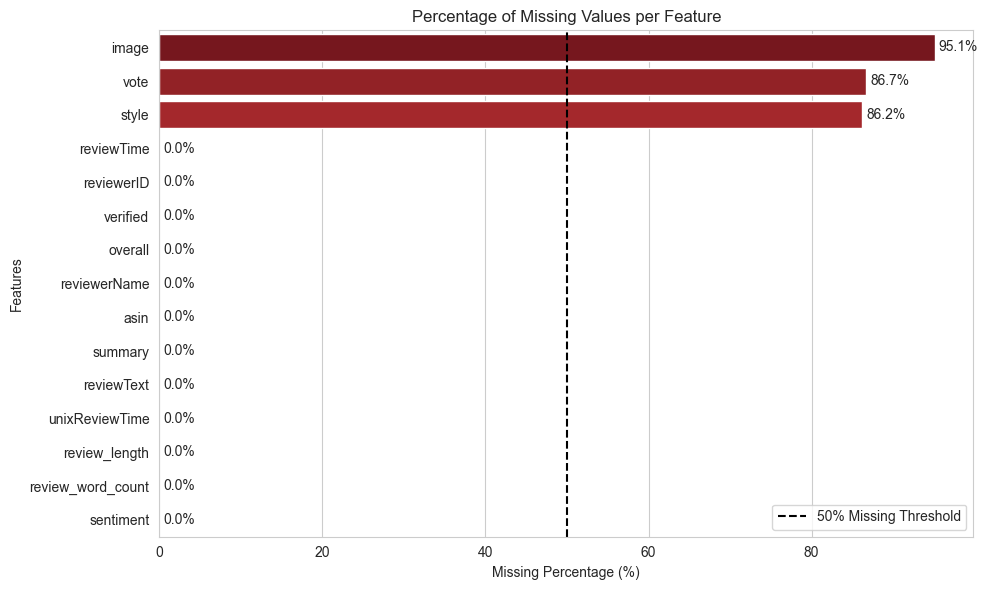

Dropped columns: ['style', 'image', 'unixReviewTime', 'reviewerName']
Remaining columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewText', 'summary', 'vote', 'review_length', 'review_word_count', 'sentiment']


In [19]:
# Enhancement
# --- Statistical Justification for Column Selection ---

# Calculate missing value percentages
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percentages.reset_index()
missing_df.columns = ['Feature', 'Missing_Percentage']
missing_df = missing_df.sort_values(by='Missing_Percentage', ascending=False)

# Plot: Missing Value Percentages (with labeling)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Missing_Percentage', y='Feature', data=missing_df, palette='Reds_r', ax=ax)
ax.set_title("Percentage of Missing Values per Feature")
ax.set_xlabel("Missing Percentage (%)")
ax.set_ylabel("Features")
ax.axvline(50, color='black', linestyle='--', label='50% Missing Threshold')

# Add exact percentage labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.legend()
plt.tight_layout()
plt.savefig("outputs/missing_values_justification.png", dpi=150)
plt.show()

# Drop unjustified columns based on the statistics and redundancy
columns_to_drop = [
    'style',             # Dropped due to > 98% missing values
    'image',             # Dropped due to > 63% missing values
    'unixReviewTime',    # Dropped due to perfect redundancy with 'reviewTime'
    'reviewerName'       # Dropped due to redundancy with unique 'reviewerID' 
]

df_cleaned = df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")
print(f"Remaining columns: {df_cleaned.columns.tolist()}")

We choose 'reviewText' as the primary column for sentiment analysis because it contains the full customer opinion.  
We also keep 'summary' as it provides a condensed version that can reinforce sentiment signals.
'overall' is kept as ground truth.  'asin' and 'reviewerID' are kept for identification.

In [20]:
COLUMNS_USED = [
    "reviewerID",
    "asin",
    "overall",
    "reviewText",
    "summary",
    "sentiment",
    "review_word_count",
]
df = df[[c for c in COLUMNS_USED if c in df.columns]].copy()
print(f"\nColumns selected for analysis: {df.columns.tolist()}")


Columns selected for analysis: ['reviewerID', 'asin', 'overall', 'reviewText', 'summary', 'sentiment', 'review_word_count']


In [21]:
empty_reviews = (df["reviewText"].str.strip() == "").sum()
print(f"\nEmpty review texts: {empty_reviews}")
# Remove empty reviews
df = df[df["reviewText"].str.strip() != ""].reset_index(drop=True)
print(f"Dataset after removing empty reviews: {len(df)} reviews")


Empty review texts: 0
Dataset after removing empty reviews: 203 reviews


# TEXT PRE-PROCESSING FOR EACH LEXICON

We studied three lexicon packages:

1. VADER (Valence Aware Dictionary and Sentiment Reasoner)
   - Specifically tuned for social media / short informal text
   - Handles capitalization, punctuation emphasis, slang, emojis
   - Returns compound score (-1 to +1)
   - Works well WITHOUT removing stop words or punctuation

2. TextBlob
   - Built on Pattern library and NLTK
   - Returns polarity (-1 to +1) and subjectivity (0 to 1)
   - General-purpose, easy to use
   - Works well on standard English text

3. SentiWordNet
   - Assigns positivity/negativity/objectivity to WordNet synsets
   - Requires POS tagging and word-sense disambiguation
   - More complex to implement; best for fine-grained analysis

CHOSEN: VADER and TextBlob
- VADER excels on informal review text (handles emphasis, negation well)
- TextBlob provides a good general-purpose baseline for comparison
- Both are straightforward to apply and compare
- SentiWordNet was also implemented for comparison.


### Improvement
- The original approach is to take the reviewText as the content for all 3 Lexicon models.
- A new feature is created by combining summary and reviewText and passed to all 3 models.
- Improvement are seen with this new feature.

===== Comparison Table Before Enhancement =====
| Metric               | VADER  | TextBlob | SentiWordNet |
| -------------------- | ------ | -------- | ------------ |
| Accuracy             | 0.7783 | 0.7044   | 0.7389       |
| Precision (weighted) | 0.8164 | 0.8279   | 0.8558       |
| Recall (weighted)    | 0.7783 | 0.7044   | 0.7389       |
| F1 (weighted)        | 0.7947 | 0.7486   | 0.784        |

===== Comparison Table After Enhancement =====
| Metric               | VADER  | TextBlob | SentiWordNet |
| -------------------- | ------ | -------- | ------------ |
| Accuracy             | 0.7833 | 0.7389   | 0.7685       |
| Precision (weighted) | 0.8227 | 0.8312   | 0.8619       |
| Recall (weighted)    | 0.7833 | 0.7389   | 0.7685       |
| F1 (weighted)        | 0.7972 | 0.7706   | 0.806        |

In [22]:
# Enhancement
# Enhanced: Combine 'summary' and 'reviewText' for richer context in the analysis

# df["text_for_vader"] = df["reviewText"].str.strip()

enhance = True  # Set to False to skip enhancement
if enhance:
    df['full_review'] = df['summary'] + " " + df['reviewText']
else:
    df['full_review'] = df['reviewText']

df["text_for_vader"] = df["full_review"].str.strip()

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_for_textblob(text):
    """Clean text for TextBlob analysis."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"<.*?>", "", text)  # remove HTML
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters & spaces
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if len(t) > 1]
    return " ".join(tokens)

# Specialized Pre-processing for SentiWordNet
def preprocess_for_swn(text):
    """Clean text for SentiWordNet (Keeping structure for POS tagging)."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"<.*?>", "", text)           # remove HTML
    # We do NOT remove punctuation or lemmatize here 
    # so the POS tagger can work effectively.
    return text.strip()


# df["text_for_textblob"] = df["reviewText"].apply(preprocess_for_textblob)
# df["text_for_swn"] = df["reviewText"].apply(preprocess_for_swn)

df["text_for_textblob"] = df["full_review"].apply(preprocess_for_textblob)
df["text_for_swn"] = df["full_review"].apply(preprocess_for_swn)



print("\n--- Sample (first review) ---")
# print(f"Original      : {df['reviewText'].iloc[0][:120]}...")
print(f"Original      : {df['full_review'].iloc[0][:120]}...")
print(f"For VADER     : {df['text_for_vader'].iloc[0][:120]}...")
print(f"For TextBlob  : {df['text_for_textblob'].iloc[0][:120]}...")
print(f"For SentiWordNet: {df['text_for_swn'].iloc[0][:120]}...")


--- Sample (first review) ---
Original      : Great product I like this as a vent as well as something that will keep house warmer in winter.  I sanded it and then pa...
For VADER     : Great product I like this as a vent as well as something that will keep house warmer in winter.  I sanded it and then pa...
For TextBlob  : great product like this a vent a well a something that will keep house warmer in winter sanded it and then painted it th...
For SentiWordNet: great product i like this as a vent as well as something that will keep house warmer in winter.  i sanded it and then pa...


# SAMPLE 1000 REVIEWS

In [23]:
SAMPLE_SIZE = min(1000, len(df))
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Randomly selected {SAMPLE_SIZE} reviews (random_state=42)")
print(f"Sentiment distribution in sample:\n{df_sample['sentiment'].value_counts()}")

Randomly selected 203 reviews (random_state=42)
Sentiment distribution in sample:
sentiment
Positive    178
Negative     16
Neutral       9
Name: count, dtype: int64


# MODELING – LEXICON APPROACH

In [24]:
print("\n--- VADER Model ---")
vader_analyzer = SentimentIntensityAnalyzer()


def vader_predict(text):
    """Classify sentiment using VADER compound score."""
    scores = vader_analyzer.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"


df_sample["vader_pred"] = df_sample["text_for_vader"].apply(vader_predict)
df_sample["vader_compound"] = df_sample["text_for_vader"].apply(
    lambda x: vader_analyzer.polarity_scores(x)["compound"]
)

print("VADER predictions (sample):")
print(df_sample["vader_pred"].value_counts())


--- VADER Model ---
VADER predictions (sample):
vader_pred
Positive    174
Neutral      24
Negative      5
Name: count, dtype: int64


In [25]:
print("\n--- TextBlob Model ---")


def textblob_predict(text):
    """Classify sentiment using TextBlob polarity."""
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"


df_sample["textblob_pred"] = df_sample["text_for_textblob"].apply(textblob_predict)
df_sample["textblob_polarity"] = df_sample["text_for_textblob"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

print("TextBlob predictions (sample):")
print(df_sample["textblob_pred"].value_counts())


--- TextBlob Model ---
TextBlob predictions (sample):
textblob_pred
Positive    165
Neutral      36
Negative      2
Name: count, dtype: int64


In [26]:
# Enhancement
print("\n--- SentiWordNet Model ---")

# Helper function to map NLTK tags to WordNet tags
def get_wordnet_pos(treebank_tag):
    """Maps POS tags to format SentiWordNet understands."""
    if treebank_tag.startswith('J'): return wn.ADJ
    elif treebank_tag.startswith('V'): return wn.VERB
    elif treebank_tag.startswith('N'): return wn.NOUN
    elif treebank_tag.startswith('R'): return wn.ADV
    return None

# Main Scoring and Prediction function
def get_swn_score_and_label(text):
    """
    Calculates SentiWordNet score by identifying POS tags and summing 
    synset polarity. Returns both the raw score and the label.
    """
    sentiment_score = 0.0
    tokens = word_tokenize(text)
    tagged = nltk.pos_tag(tokens)
    
    for word, tag in tagged:
        wn_tag = get_wordnet_pos(tag)
        if not wn_tag:
            continue
        
        # Look up the synset (word meaning)
        synsets = list(swn.senti_synsets(word, wn_tag))
        if not synsets:
            continue
        
        # # Take the most common synset (the first one)
        # synset = synsets[0]
        # # Aggregate Score: Positive score - Negative score
        # sentiment_score += (synset.pos_score() - synset.neg_score())

        # Instead of: synset = synsets[0]
        
        # Try: Averaging all senses of the word
        pos_all = sum(s.pos_score() for s in synsets) / len(synsets)
        neg_all = sum(s.neg_score() for s in synsets) / len(synsets)
        sentiment_score += (pos_all - neg_all)
    
    # Labeling logic based on the score (Thresholding)
    if sentiment_score > 0.05:
        label = "Positive"
    elif sentiment_score < -0.05:
        label = "Negative"
    else:
        label = "Neutral"
        
    return sentiment_score, label

# --- APPLYING TO DATAFRAME ---

# Apply scoring and split into two columns: swn_score and swn_pred
swn_results = df_sample['text_for_swn'].apply(get_swn_score_and_label)
df_sample['swn_score'] = [x[0] for x in swn_results]
df_sample['swn_pred'] = [x[1] for x in swn_results]

# print("SentiWordNet Processing Complete.")
# print(df_sample[['reviewText', 'swn_score', 'swn_pred']].head())


print("SentiWordNet predictions (sample):")
print(df_sample["swn_pred"].value_counts())


--- SentiWordNet Model ---
SentiWordNet predictions (sample):
swn_pred
Positive    152
Negative     29
Neutral      22
Name: count, dtype: int64


# VALIDATION & COMPARISON

In [27]:
labels = ["Positive", "Neutral", "Negative"]
y_true = df_sample["sentiment"]

## VADER METRICS


===== VADER Classification Report =====
              precision    recall  f1-score   support

    Positive       0.90      0.88      0.89       178
     Neutral       0.00      0.00      0.00         9
    Negative       0.40      0.12      0.19        16

    accuracy                           0.78       203
   macro avg       0.43      0.34      0.36       203
weighted avg       0.82      0.78      0.80       203



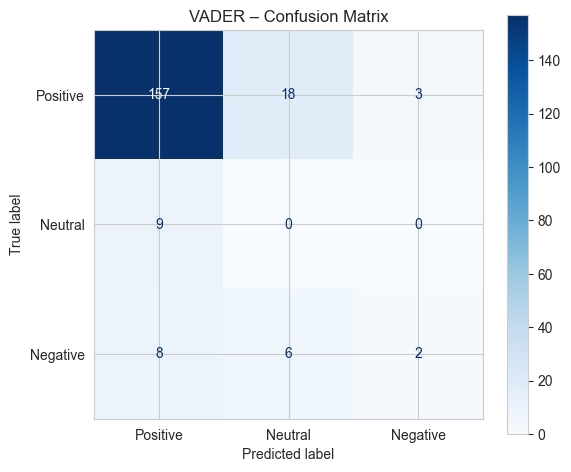

In [28]:
y_vader = df_sample["vader_pred"]
print("\n===== VADER Classification Report =====")
print(
    classification_report(
        y_true, y_vader, labels=labels, target_names=labels, zero_division=0
    )
)

vader_acc = accuracy_score(y_true, y_vader)
vader_prec = precision_score(y_true, y_vader, average="weighted", zero_division=0)
vader_rec = recall_score(y_true, y_vader, average="weighted", zero_division=0)
vader_f1 = f1_score(y_true, y_vader, average="weighted", zero_division=0)

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_vader = confusion_matrix(y_true, y_vader, labels=labels)
ConfusionMatrixDisplay(cm_vader, display_labels=labels).plot(ax=ax, cmap="Blues")
ax.set_title("VADER – Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_vader.png", dpi=150)
plt.show()

## TextBlob Metrics


===== TextBlob Classification Report =====
              precision    recall  f1-score   support

    Positive       0.90      0.84      0.87       178
     Neutral       0.00      0.00      0.00         9
    Negative       0.50      0.06      0.11        16

    accuracy                           0.74       203
   macro avg       0.47      0.30      0.33       203
weighted avg       0.83      0.74      0.77       203



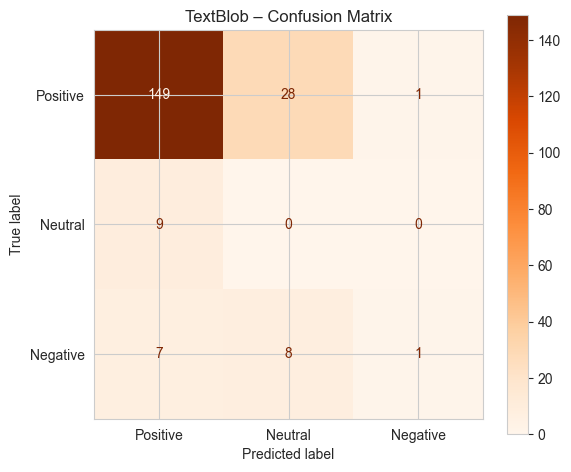

In [29]:
y_textblob = df_sample["textblob_pred"]
print("\n===== TextBlob Classification Report =====")
print(
    classification_report(
        y_true, y_textblob, labels=labels, target_names=labels, zero_division=0
    )
)

tb_acc = accuracy_score(y_true, y_textblob)
tb_prec = precision_score(y_true, y_textblob, average="weighted", zero_division=0)
tb_rec = recall_score(y_true, y_textblob, average="weighted", zero_division=0)
tb_f1 = f1_score(y_true, y_textblob, average="weighted", zero_division=0)

fig, ax = plt.subplots(figsize=(6, 5))
cm_tb = confusion_matrix(y_true, y_textblob, labels=labels)
ConfusionMatrixDisplay(cm_tb, display_labels=labels).plot(ax=ax, cmap="Oranges")
ax.set_title("TextBlob – Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_textblob.png", dpi=150)
plt.show()

## SentiWordNet Metrics


===== SentiWordNet Classification Report =====
              precision    recall  f1-score   support

    Positive       0.95      0.81      0.87       178
     Neutral       0.09      0.22      0.13         9
    Negative       0.34      0.62      0.44        16

    accuracy                           0.77       203
   macro avg       0.46      0.55      0.48       203
weighted avg       0.86      0.77      0.81       203



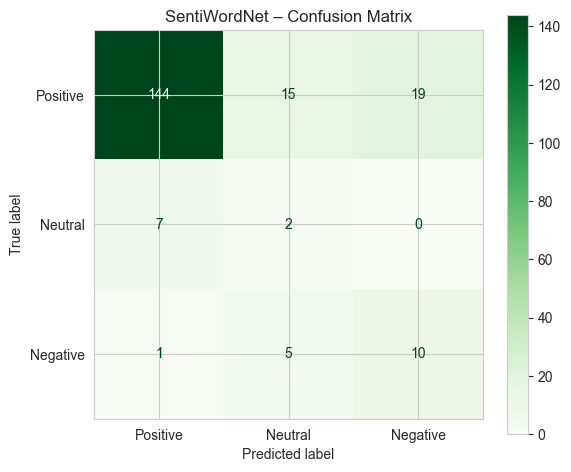

In [30]:
# Enhancement
y_swn = df_sample["swn_pred"]
print("\n===== SentiWordNet Classification Report =====")
print(
    classification_report(
        y_true, y_swn, labels=labels, target_names=labels, zero_division=0
    )
)

swn_acc = accuracy_score(y_true, y_swn)
swn_prec = precision_score(y_true, y_swn, average="weighted", zero_division=0)
swn_rec = recall_score(y_true, y_swn, average="weighted", zero_division=0)
swn_f1 = f1_score(y_true, y_swn, average="weighted", zero_division=0)

fig, ax = plt.subplots(figsize=(6, 5))
cm_swn = confusion_matrix(y_true, y_swn, labels=labels)
ConfusionMatrixDisplay(cm_swn, display_labels=labels).plot(ax=ax, cmap="Greens")
ax.set_title("SentiWordNet – Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/cm_swn.png", dpi=150)
plt.show()

## Comparison Table


===== Comparison Table =====
              Metric  VADER TextBlob SentiWordNet
            Accuracy 0.7833   0.7389       0.7685
Precision (weighted) 0.8227   0.8312       0.8619
   Recall (weighted) 0.7833   0.7389       0.7685
       F1 (weighted) 0.7972   0.7706       0.8060


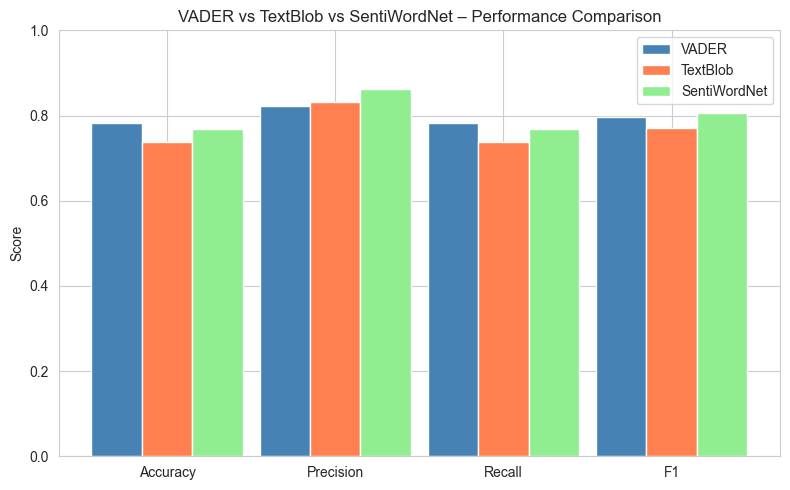

In [31]:
# Enhancement
print("\n===== Comparison Table =====")
comparison = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"],
        "VADER": [
            f"{vader_acc:.4f}",
            f"{vader_prec:.4f}",
            f"{vader_rec:.4f}",
            f"{vader_f1:.4f}",
        ],
        "TextBlob": [
            f"{tb_acc:.4f}",
            f"{tb_prec:.4f}",
            f"{tb_rec:.4f}",
            f"{tb_f1:.4f}",
        ],
        "SentiWordNet": [
            f"{swn_acc:.4f}",
            f"{swn_prec:.4f}",
            f"{swn_rec:.4f}",
            f"{swn_f1:.4f}",
        ],
    }
)
print(comparison.to_string(index=False))

# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(4)
width = 0.3
vals_vader = [vader_acc, vader_prec, vader_rec, vader_f1]
vals_tb = [tb_acc, tb_prec, tb_rec, tb_f1]
vals_swn = [swn_acc, swn_prec, swn_rec, swn_f1]

ax.bar(x - width , vals_vader, width, label="VADER", color="steelblue")
ax.bar(x , vals_tb, width, label="TextBlob", color="coral")
ax.bar(x + width , vals_swn, width, label="SentiWordNet", color="lightgreen")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("VADER vs TextBlob vs SentiWordNet – Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/comparison_chart.png", dpi=150)
plt.show()

### Score distribution plots

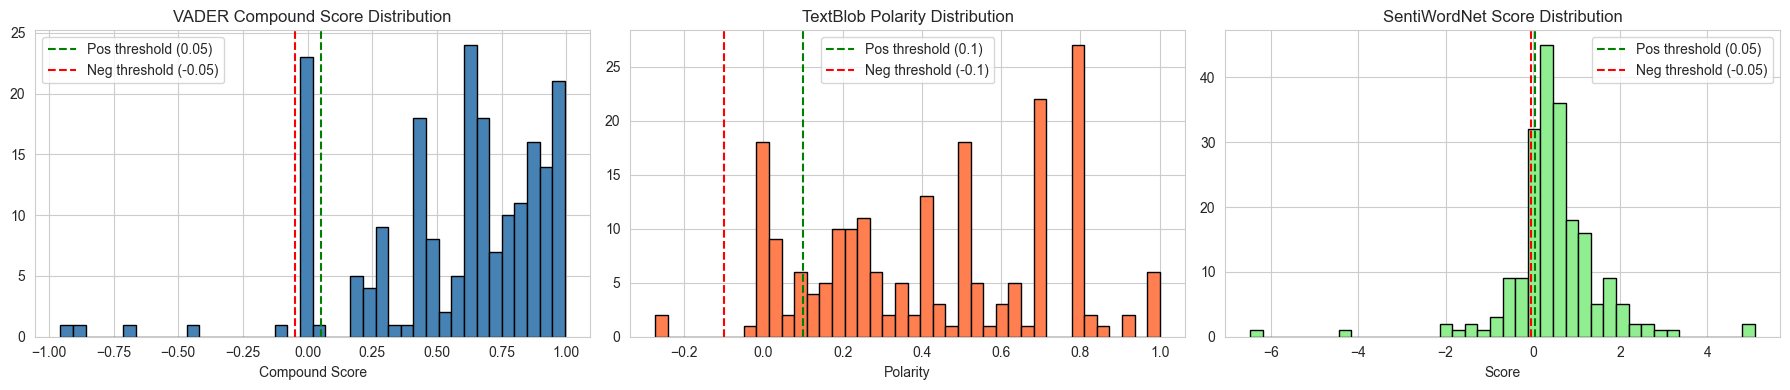

In [32]:
# Enhancement
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df_sample["vader_compound"], bins=40, color="steelblue", edgecolor="black")
axes[0].axvline(0.05, color="green", linestyle="--", label="Pos threshold (0.05)")
axes[0].axvline(-0.05, color="red", linestyle="--", label="Neg threshold (-0.05)")
axes[0].set_title("VADER Compound Score Distribution")
axes[0].set_xlabel("Compound Score")
axes[0].legend()

axes[1].hist(
    df_sample["textblob_polarity"], bins=40, color="coral", edgecolor="black"
)
axes[1].axvline(0.1, color="green", linestyle="--", label="Pos threshold (0.1)")
axes[1].axvline(-0.1, color="red", linestyle="--", label="Neg threshold (-0.1)")
axes[1].set_title("TextBlob Polarity Distribution")
axes[1].set_xlabel("Polarity")
axes[1].legend()

axes[2].hist(
    df_sample["swn_score"], bins=40, color="lightgreen", edgecolor="black"
)
axes[2].axvline(0.05, color="green", linestyle="--", label="Pos threshold (0.05)")
axes[2].axvline(-0.05, color="red", linestyle="--", label="Neg threshold (-0.05)")
axes[2].set_title("SentiWordNet Score Distribution")
axes[2].set_xlabel("Score")
axes[2].legend()

plt.tight_layout()
plt.savefig("outputs/score_distributions.png", dpi=150)
plt.show()

In [33]:
df_sample.to_csv("outputs/phase1_results.csv", index=False)
print("\nResults saved to outputs/phase1_results.csv")
print("\nPhase #1 complete!")


Results saved to outputs/phase1_results.csv

Phase #1 complete!
